# ¿Qué sectores pagan más? Compensación ejecutiva ajustada por tamaño

Archivo `07. T1_GC_datos.xlsx`, año fiscal 2023. Tres columnas de compensación del archivo:

| Columna | Variable                                         | Contenido                                    |
| ------- | ------------------------------------------------ | -------------------------------------------- |
| **AT**  | `Total Compensation Paid to Executives`          | Suma pagada a todo el equipo ejecutivo (USD) |
| **AU**  | `Total Compensation Paid to CEO and Equivalent`  | Solo el CEO (USD)                            |
| **AV**  | `Total Board of Director Compensation Paid`      | Junta directiva (USD)                        |
| **AW**  | `Number of CEO and Equivalent Changes During FY` | Cambios de CEO en el año                     |

**Nota sobre las columnas pedidas.** AW no es una variable de compensación sino de rotación
del CEO. Se conserva, pero como variable de corte en la sección 6: sirve para separar el pago
recurrente del pago de salida. Se agrega AU porque sin ella no se puede distinguir cuánto del
paquete ejecutivo se concentra en una sola persona.

**El problema central.** El nivel absoluto de compensación mide sobre todo el tamaño de la
empresa. Comparar el pago mediano de Tecnología contra el de Servicios Públicos sin corregir
por tamaño responde a la pregunta equivocada. Aquí se normaliza de dos formas:

1. **Razones simples:** pago por cada USD 1.000 millones de ingresos, por empleado, y en
   puntos básicos de capitalización bursátil.
2. **Regresión log-log con efectos de sector:** `log(pago) ~ log(tamaño) + sector`. El
   coeficiente del sector es la **prima**: cuánto paga de más o de menos ese sector frente a
   lo que su tamaño predice.


## 1. Carga y construcción de variables


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_excel("07. T1_GC_datos.xlsx", sheet_name="datos")
df = df.drop(
    columns=[c for c in df.columns if c.endswith(".1")]
)  # duplicadas del archivo

RENOMBRES = {
    "Industry Sector": "Sector",
    "Total Compensation Paid to Executives": "CompEjec",  # AT
    "Total Compensation Paid to CEO and Equivalent": "CompCEO",  # AU
    "Total Board of Director Compensation Paid": "CompJunta",  # AV
    "Number of CEO and Equivalent Changes During FY": "CambiosCEO",  # AW
    "Number of Directors Included Compensation Paid": "NDirPagados",
    "Number of Employees": "Empleados",
    "Revenue": "Ingresos",
    "Total Assets": "Activos",
    "Current Market Cap": "MCAP",
    "Return on Assets": "ROA",
    "Operating Margin": "MargenOp",
    "BESG Governance Pillar Score": "G",
}
df = df.rename(columns=RENOMBRES)

# Unidades del archivo: Ingresos, Activos y EBITDA vienen en millones de USD;
# MCAP y las tres columnas de compensación vienen en USD. Se homogeneiza a USD.
for c in ["Ingresos", "Activos"]:
    df[c + "_usd"] = df[c] * 1e6

print(f"Filas: {len(df):,}   Sectores: {df['Sector'].nunique()}")
df[["Ticker", "Sector", "CompEjec", "CompCEO", "CompJunta", "CambiosCEO"]].head()

Filas: 1,878   Sectores: 10


,Ticker,Sector,CompEjec,CompCEO,CompJunta,CambiosCEO
0,AAPL US Equity,Technology,"183,325,385.00","74,609,802.00","3,099,264.00",0.00
1,MSFT US Equity,Technology,"163,430,212.00","79,106,183.00","4,230,000.00",0.00
2,NVDA US Equity,Technology,"83,157,547.00","34,167,902.00","4,892,588.00",0.00
3,AMZN US Equity,Communications,"4,600,271.00","1,357,764.00","4,514,830.00",0.00
4,GOOGL US Equity,Communications,"147,396,768.00","8,802,824.00","3,627,134.00",0.00


### 1.1 Cobertura: el sector _Funds_ no tiene datos de compensación

383 de las 1.878 filas son fondos cotizados. No tienen ejecutivos, ingresos ni empleados en el
sentido del resto de la muestra y su compensación está vacía en el 100% de los casos. Se
excluyen: dejarlos dentro solo mete ceros y NaN en cada agrupación.


In [2]:
cobertura = (
    df.groupby("Sector")[["CompEjec", "CompCEO", "CompJunta", "Ingresos", "Empleados"]]
    .apply(lambda d: d.notna().sum())
    .assign(filas=df["Sector"].value_counts())
)
cobertura["pct_CompEjec"] = (100 * cobertura["CompEjec"] / cobertura["filas"]).round(1)
print(cobertura.sort_values("filas", ascending=False).to_string())

d = df[df["Sector"] != "Funds"].copy()
print(
    f"\nMuestra de trabajo: {len(d):,} empresas operativas, "
    f"{d['CompEjec'].notna().sum():,} con dato de compensación ejecutiva "
    f"({100 * d['CompEjec'].notna().mean():.0f}%)."
)

                        CompEjec  CompCEO  CompJunta  Ingresos  Empleados  filas  pct_CompEjec
Sector                                                                                        
Funds                          0        0          0         0          0    383          0.00
Financial                    299      293        303       311        301    312         95.80
Consumer, Non-cyclical       278      271        281       294        288    295         94.20
Industrial                   207      206        208       214        205    215         96.30
Consumer, Cyclical           184      180        184       199        190    200         92.00
Technology                   173      169        171       193        175    193         89.60
Communications                86       76         81        99         94     99         86.90
Energy                        70       69         71        76         71     76         92.10
Utilities                     52       52         

La cobertura de las tres columnas de compensación es del 90% dentro de las empresas operativas
y es pareja entre sectores. Ese es el punto importante: la comparación entre sectores no está
contaminada por diferencias de reporte.


## 2. Nivel absoluto: la respuesta equivocada


In [3]:
COMP = ["CompEjec", "CompCEO", "CompJunta"]

nivel = d.groupby("Sector")[COMP].median()
nivel["n"] = d.groupby("Sector")["CompEjec"].count()
nivel = nivel.sort_values("CompEjec", ascending=False)
print("Mediana de compensación por sector (USD):")
nivel

Mediana de compensación por sector (USD):


,CompEjec,CompCEO,CompJunta,n
Sector,,,,
Communications,"33,163,728.00","14,882,119.00","2,728,879.00",86
Technology,"32,480,316.00","13,405,690.00","2,445,000.00",173
"Consumer, Cyclical","26,903,574.00","11,639,330.50","2,563,357.00",184
Energy,"26,304,792.50","11,254,921.00","2,480,405.00",70
Basic Materials,"26,214,832.00","11,881,204.00","2,851,421.00",47
"Consumer, Non-cyclical","25,677,129.00","11,650,671.00","2,915,955.00",278
Financial,"23,500,617.00","9,479,687.00","2,357,113.00",299
Industrial,"20,899,886.00","9,321,739.50","2,407,500.50",207
Utilities,"20,557,971.00","8,831,298.50","2,690,908.00",52


In [4]:
tam = d.groupby("Sector")[["Ingresos", "MCAP", "Empleados"]].median()
tam["MCAP_bn"] = tam["MCAP"] / 1e9
comparacion = nivel[["CompEjec"]].join(tam[["Ingresos", "MCAP_bn", "Empleados"]])

print("Compensación ejecutiva mediana vs. tamaño mediano del sector:")
print(comparacion.to_string())

# La correlación relevante es a nivel de empresa, no de mediana sectorial (9 puntos).
sub = d[["CompEjec", "MCAP", "Ingresos", "Empleados"]].dropna()
print("\nSpearman a nivel empresa entre compensación ejecutiva y tamaño:")
for v in ["MCAP", "Ingresos", "Empleados"]:
    print(
        f"  {v:10s} rho = {sub['CompEjec'].corr(sub[v], method='spearman'):+.3f}  (n = {len(sub):,})"
    )

rho_sec = comparacion["CompEjec"].corr(comparacion["MCAP_bn"], method="spearman")
print(
    f"\nSpearman entre medianas sectoriales (CompEjec, MCAP) = {rho_sec:+.2f}  "
    "→ con 9 puntos y Utilities como caso atípico, la mediana sectorial no informa."
)

Compensación ejecutiva mediana vs. tamaño mediano del sector:
                            CompEjec  Ingresos  MCAP_bn  Empleados
Sector                                                            
Communications         33,163,728.00  7,039.59    15.36   9,328.50
Technology             32,480,316.00  2,207.10    10.12   6,450.00
Consumer, Cyclical     26,903,574.00  6,702.00     8.12  15,000.00
Energy                 26,304,792.50  5,103.77     8.83   2,300.00
Basic Materials        26,214,832.00  8,653.99     8.32  13,471.50
Consumer, Non-cyclical 25,677,129.00  3,801.62     8.73  10,200.00
Financial              23,500,617.00  2,987.31     7.89   3,168.00
Industrial             20,899,886.00  4,596.40     8.27  14,000.00
Utilities              20,557,971.00  5,455.10    16.24   6,403.00

Spearman a nivel empresa entre compensación ejecutiva y tamaño:
  MCAP       rho = +0.575  (n = 1,363)
  Ingresos   rho = +0.542  (n = 1,363)
  Empleados  rho = +0.447  (n = 1,363)

Spearman entre med

Comunicaciones y Tecnología encabezan la tabla en nivel absoluto. A nivel de empresa, la
compensación ejecutiva correlaciona fuerte con las tres medidas de tamaño (rho de Spearman
entre +0,45 y +0,58): **la mayor parte de la variación del pago es variación de tamaño.**

La correlación entre medianas sectoriales es baja, pero eso no contradice lo anterior: son solo
nueve puntos y Servicios Públicos los rompe, porque tiene la capitalización mediana más alta de
la muestra y el pago mediano más bajo. Ese sector es exactamente el que hay que explicar, y
para eso hace falta el ajuste por tamaño a nivel empresa.


## 3. Normalización 1: razones simples

Tres denominadores, tres preguntas distintas:

- **Por cada USD 1.000 M de ingresos** — cuánto cuesta la cúpula frente a la escala del negocio.
- **Por empleado** — cuánto pesa la cúpula frente a la nómina que dirige.
- **En puntos básicos del _market cap_** — cuánto cuesta la cúpula al accionista.

Ninguna es neutral. Un banco tiene pocos ingresos contables y muchos activos; una petrolera
tiene ingresos enormes y poca gente. Por eso se reportan las tres.


In [5]:
d["Comp_por_1000M_ing"] = d["CompEjec"] / (d["Ingresos_usd"] / 1e9)
d["Comp_por_empleado"] = d["CompEjec"] / d["Empleados"]
d["Comp_bps_MCAP"] = 1e4 * d["CompEjec"] / d["MCAP"]
d["CompJunta_por_dir"] = d["CompJunta"] / d["NDirPagados"]
d["CEO_sobre_ejec"] = d["CompCEO"] / d["CompEjec"]

RATIOS = ["Comp_por_1000M_ing", "Comp_por_empleado", "Comp_bps_MCAP"]
razones = d.groupby("Sector")[RATIOS].median()
razones["n"] = d.groupby("Sector")["CompEjec"].count()
print("Mediana por sector de las tres razones:")
razones.sort_values("Comp_bps_MCAP", ascending=False)

Mediana por sector de las tres razones:


,Comp_por_1000M_ing,Comp_por_empleado,Comp_bps_MCAP,n
Sector,,,,
Basic Materials,"3,093,074.74","2,141.80",25.52,47
"Consumer, Non-cyclical","5,704,837.41","2,269.73",25.19,278
"Consumer, Cyclical","3,533,660.14","1,383.92",24.42,184
Technology,"14,408,899.95","5,113.79",22.59,173
Financial,"6,365,263.34","5,980.70",22.34,299
Industrial,"4,341,451.73","1,581.75",22.14,207
Communications,"4,612,567.13","3,252.79",20.45,86
Energy,"3,689,994.40","9,883.40",19.93,70
Utilities,"3,859,351.42","4,073.96",12.62,52


In [6]:
# Ranking de cada sector bajo cada denominador (1 = paga más)
rank = razones[RATIOS].rank(ascending=False).astype(int)
rank["nivel_absoluto"] = nivel["CompEjec"].rank(ascending=False).astype(int)
rank = rank[["nivel_absoluto"] + RATIOS].sort_values("nivel_absoluto")
print("Posición del sector según el denominador que se use (1 = paga más):")
rank

Posición del sector según el denominador que se use (1 = paga más):


,nivel_absoluto,Comp_por_1000M_ing,Comp_por_empleado,Comp_bps_MCAP
Sector,,,,
Communications,1,4,5,7
Technology,2,1,3,4
"Consumer, Cyclical",3,8,9,3
Energy,4,7,1,8
Basic Materials,5,9,7,1
"Consumer, Non-cyclical",6,3,6,2
Financial,7,2,2,5
Industrial,8,5,8,6
Utilities,9,6,4,9


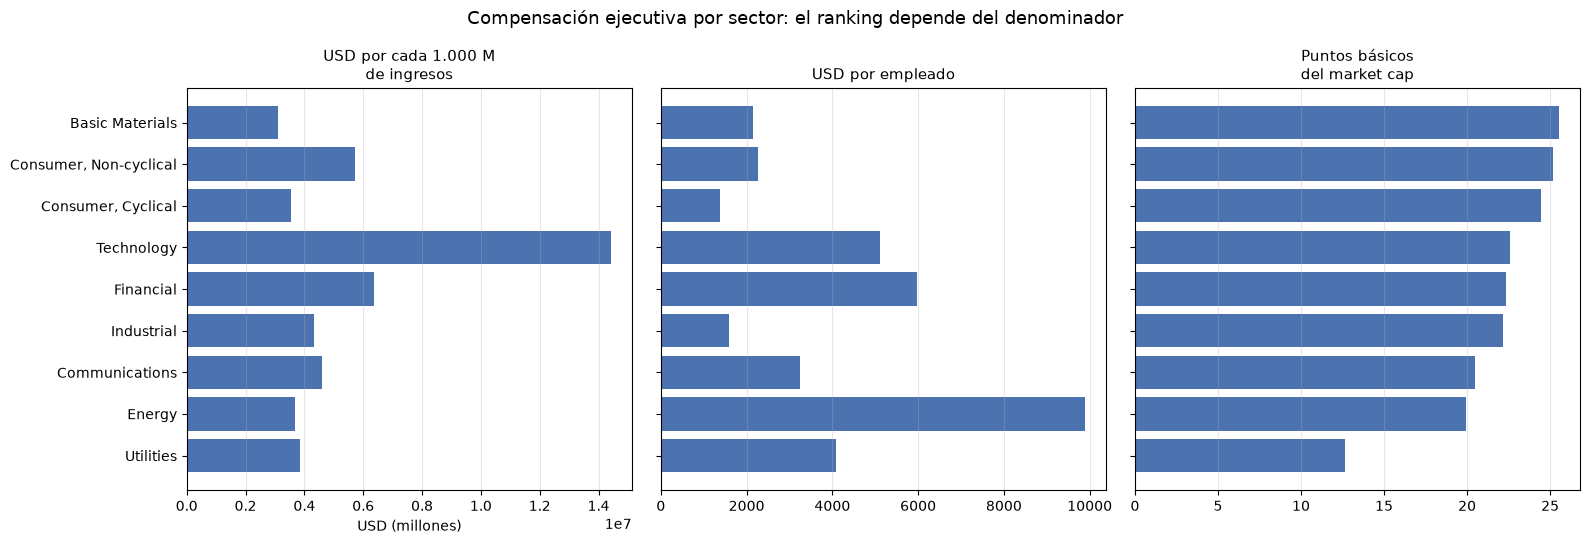

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
titulos = {
    "Comp_por_1000M_ing": "USD por cada 1.000 M\nde ingresos",
    "Comp_por_empleado": "USD por empleado",
    "Comp_bps_MCAP": "Puntos básicos\ndel market cap",
}
orden = razones.sort_values("Comp_bps_MCAP").index
for ax, col in zip(axes, RATIOS):
    s = razones.loc[orden, col]
    ax.barh(s.index, s.values, color="#4C72B0")
    ax.set_title(titulos[col], fontsize=11)
    ax.grid(axis="y", alpha=0)
axes[0].set_xlabel("USD (millones)")
fig.suptitle(
    "Compensación ejecutiva por sector: el ranking depende del denominador", fontsize=13
)
fig.tight_layout()
plt.show()

El ranking se reordena por completo según el denominador. Comunicaciones, primera en nivel
absoluto, cae al cuarto, quinto y séptimo puesto. Tecnología es primera por ingresos, Energía
es primera por empleado (pocas personas, mucho capital por cabeza) y Materiales Básicos es
primera en puntos básicos de _market cap_ pese a ser novena por ingresos. Servicios Públicos es
la última en costo para el accionista, con menos de la mitad de puntos básicos que el primero.

Las razones simples tienen un defecto: asumen que el pago escala **uno a uno** con el tamaño.
No lo hace. Ese es el trabajo de la sección siguiente.


## 4. Normalización 2: la elasticidad del pago al tamaño

La relación empírica clásica es que la compensación crece con el tamaño, pero **menos que
proporcionalmente**: duplicar la empresa no duplica el pago. Se estima

$$\log(\text{pago}) = \alpha + \beta_1 \log(\text{MCAP}) + \beta_2 \log(\text{Ingresos}) + \beta_3 \log(\text{Empleados}) + \varepsilon$$

Si $\sum \beta < 1$, dividir el pago por el tamaño (sección 3) **castiga mecánicamente a las
empresas grandes** y por lo tanto a los sectores de empresas grandes.


In [8]:
def winsorizar(s, p=0.01):
    """Recorta a los percentiles [p, 1-p]. Las colas de compensación son extremas."""
    lo, hi = s.quantile([p, 1 - p])
    return s.clip(lo, hi)


TAMANO = ["MCAP", "Ingresos_usd", "Empleados"]
for c in COMP + TAMANO:
    d["l_" + c] = np.log(winsorizar(d[c].where(d[c] > 0)))

elast = smf.ols("l_CompEjec ~ l_MCAP + l_Ingresos_usd + l_Empleados", data=d).fit(
    cov_type="HC1"
)
print(elast.summary().tables[1])
suma = elast.params[["l_MCAP", "l_Ingresos_usd", "l_Empleados"]].sum()
print(f"\nSuma de elasticidades = {suma:.3f}")
print(
    "Duplicar el tamaño de la empresa multiplica el pago ejecutivo por "
    f"{2**suma:.2f}, no por 2."
)

                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          9.5267      0.427     22.286      0.000       8.689      10.365
l_MCAP             0.2461      0.020     12.449      0.000       0.207       0.285
l_Ingresos_usd     0.0673      0.029      2.294      0.022       0.010       0.125
l_Empleados        0.0315      0.019      1.671      0.095      -0.005       0.068

Suma de elasticidades = 0.345
Duplicar el tamaño de la empresa multiplica el pago ejecutivo por 1.27, no por 2.


La suma de elasticidades es cercana a 0,34. Una empresa diez veces más grande paga a su cúpula
poco más del doble, no diez veces más. Esto confirma que las razones de la sección 3 están
sesgadas contra los sectores grandes, y justifica el ajuste por regresión.


## 5. La prima de sector

Se agregan efectos fijos de sector con **codificación suma**: cada coeficiente se lee como
desviación frente al promedio de la muestra, no frente a un sector arbitrario de referencia.
La prima reportada es $100 \cdot (e^{\beta} - 1)$: el sobrepago porcentual del sector una vez
descontado su tamaño.


In [9]:
def primas(dep, data, etiqueta):
    m = smf.ols(
        f"{dep} ~ l_MCAP + l_Ingresos_usd + l_Empleados + C(Sector, Sum)", data=data
    ).fit(cov_type="HC1")
    ef = pd.DataFrame({"coef": m.params, "p": m.pvalues}).filter(like="Sector", axis=0)
    ef.index = [i.split("S.")[1].rstrip("]") for i in ef.index]
    # La codificación suma omite un sector; su coeficiente es menos la suma de los demás.
    omitido = [s for s in data["Sector"].dropna().unique() if s not in ef.index][0]
    ef.loc[omitido] = [-ef["coef"].sum(), np.nan]
    ef[etiqueta] = 100 * (np.exp(ef["coef"]) - 1)
    ef["p_" + etiqueta] = ef["p"]
    return m, ef[[etiqueta, "p_" + etiqueta]].sort_values(etiqueta, ascending=False)


m_ejec, p_ejec = primas("l_CompEjec", d, "prima_ejec_%")
print(f"Ejecutivos (AT): n = {int(m_ejec.nobs):,}, R² = {m_ejec.rsquared:.3f}")
p_ejec

Ejecutivos (AT): n = 1,349, R² = 0.342


,prima_ejec_%,p_prima_ejec_%
Technology,37.67,0.00
"Consumer, Non-cyclical",4.40,0.25
Communications,2.50,0.82
Financial,2.09,0.60
"Consumer, Cyclical",0.92,0.85
Energy,-0.74,0.92
Basic Materials,-3.37,0.65
Industrial,-10.60,0.00
Utilities,-23.16,NaN


In [10]:
m_ceo, p_ceo = primas("l_CompCEO", d, "prima_CEO_%")
m_junta, p_junta = primas("l_CompJunta", d, "prima_junta_%")

tabla_primas = (
    p_ejec[["prima_ejec_%"]]
    .join(p_ceo[["prima_CEO_%"]])
    .join(p_junta[["prima_junta_%"]])
    .sort_values("prima_ejec_%", ascending=False)
)
print(
    f"CEO (AU): n = {int(m_ceo.nobs):,}, R² = {m_ceo.rsquared:.3f}   |   "
    f"Junta (AV): n = {int(m_junta.nobs):,}, R² = {m_junta.rsquared:.3f}"
)
print("\nPrima de sector sobre el pago que predice el tamaño (%):")
tabla_primas

CEO (AU): n = 1,314, R² = 0.196   |   Junta (AV): n = 1,352, R² = 0.211

Prima de sector sobre el pago que predice el tamaño (%):


,prima_ejec_%,prima_CEO_%,prima_junta_%
Technology,37.67,14.42,2.46
"Consumer, Non-cyclical",4.40,6.12,11.78
Communications,2.50,-3.23,-7.30
Financial,2.09,-1.63,-1.72
"Consumer, Cyclical",0.92,-3.26,-5.49
Energy,-0.74,-0.21,-7.55
Basic Materials,-3.37,5.45,8.21
Industrial,-10.60,-1.82,-3.34
Utilities,-23.16,-13.44,4.87


In [11]:
# La codificación suma no reporta el p-valor del sector omitido (Utilities). Se refita con
# codificación de tratamiento y base en Consumer, Non-cyclical para verificar los extremos.
chequeo = smf.ols(
    "l_CompEjec ~ l_MCAP + l_Ingresos_usd + l_Empleados + C(Sector, Treatment('Consumer, Non-cyclical'))",
    data=d,
).fit(cov_type="HC1")
ext = pd.DataFrame({"coef": chequeo.params, "p": chequeo.pvalues}).filter(
    like="Sector", axis=0
)
ext.index = [i.split("T.")[1].rstrip("]") for i in ext.index]
print("Contraste frente a Consumer, Non-cyclical (verificación de significancia):")
print(ext.loc[["Technology", "Industrial", "Utilities"]].round(4).to_string())

Contraste frente a Consumer, Non-cyclical (verificación de significancia):
            coef    p
Technology  0.28 0.00
Industrial -0.16 0.00
Utilities  -0.31 0.00


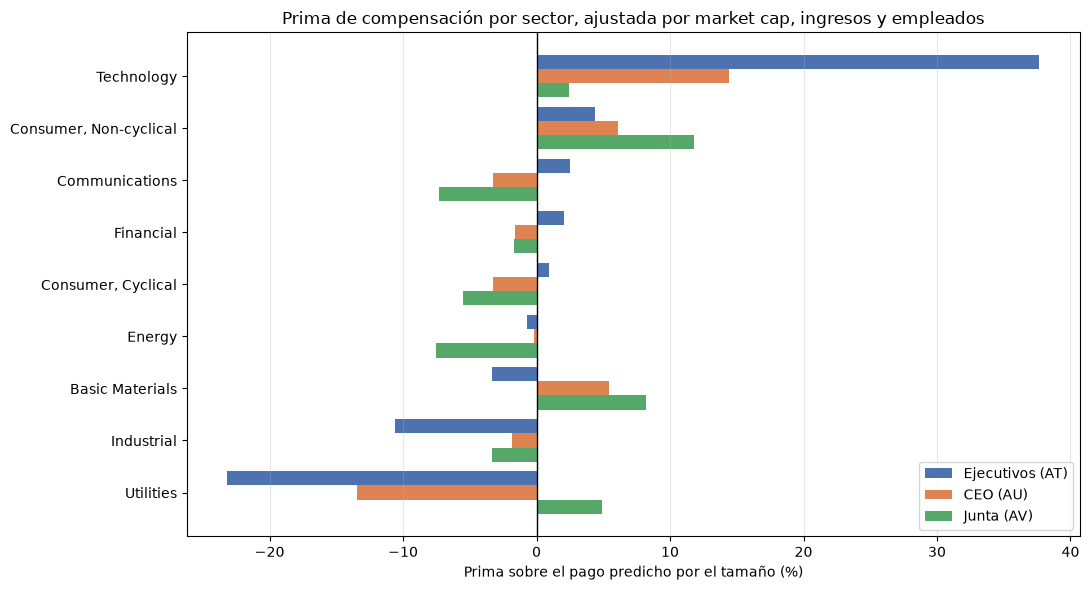

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
t = tabla_primas.sort_values("prima_ejec_%")
y = np.arange(len(t))
h = 0.27
ax.barh(y + h, t["prima_ejec_%"], h, label="Ejecutivos (AT)", color="#4C72B0")
ax.barh(y, t["prima_CEO_%"], h, label="CEO (AU)", color="#DD8452")
ax.barh(y - h, t["prima_junta_%"], h, label="Junta (AV)", color="#55A868")
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y, t.index)
ax.set_xlabel("Prima sobre el pago predicho por el tamaño (%)")
ax.set_title(
    "Prima de compensación por sector, ajustada por market cap, ingresos y empleados"
)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0)
fig.tight_layout()
plt.show()

**Tecnología es el único sector con prima ejecutiva positiva y significativa: +38% sobre lo que
predice su tamaño.** No es un efecto de escala; es pago por encima de la curva. En el extremo
opuesto están Servicios Públicos (−23%) e Industrial (−11%), ambos significativos. Servicios
Públicos es el sector regulado de la muestra y su paquete ejecutivo lo refleja.

Los otros seis sectores caen en una banda de ±5% alrededor del promedio, ninguno significativo.
Dicho de otro modo: **descontado el tamaño, la mitad de la dispersión entre sectores desaparece
y lo que queda es un solo sector caro y dos baratos.**

Tres lecturas adicionales:

- La prima del **CEO** de Tecnología (+14%) es mucho menor que la del equipo ejecutivo completo
  (+38%). El sobrepago de Tecnología está repartido en el equipo, no concentrado en el CEO.
- La prima de la **junta** casi no sigue a la de los ejecutivos. Consumo No Cíclico paga a su
  junta un 12% por encima de lo esperado mientras su equipo ejecutivo está en el promedio.
  Junta y cúpula operan como dos mercados laborales separados. Servicios Públicos lo muestra en
  su forma más clara: −23% en ejecutivos y +5% en junta.


## 6. Qué hace la columna AW: la rotación del CEO

`Number of CEO and Equivalent Changes During FY` no mide pago, pero explica una parte del pago.
Cuando hay un cambio de CEO en el año fiscal, la empresa suele reportar **dos paquetes**: la
salida del saliente y la entrada del entrante. Si eso se ignora, esas empresas se ven como
pagadoras generosas cuando en realidad están pagando una transición.

Se usa el **residuo** de la regresión sin sector como "prima ajustada por tamaño" a nivel
empresa, y se compara entre empresas con y sin cambio de CEO.


In [13]:
d.loc[elast.resid.index, "prima_empresa"] = elast.resid
d["hubo_cambio_CEO"] = d["CambiosCEO"] > 0

corte = d.groupby("hubo_cambio_CEO")[
    ["prima_empresa", "CEO_sobre_ejec", "CompEjec"]
].median()
corte.index = ["Sin cambio de CEO", "Con cambio de CEO"]
corte["n"] = d.groupby("hubo_cambio_CEO")["prima_empresa"].count().values
print(corte.to_string())

brecha = (
    corte.loc["Con cambio de CEO", "prima_empresa"]
    - corte.loc["Sin cambio de CEO", "prima_empresa"]
)
print(
    f"\nBrecha en la prima = {brecha:+.3f} log ≈ {100 * (np.exp(brecha) - 1):+.0f}% "
    "de pago ejecutivo adicional en el año del relevo."
)

                   prima_empresa  CEO_sobre_ejec      CompEjec     n
Sin cambio de CEO          -0.02            0.43 24,748,027.00  1204
Con cambio de CEO           0.24            0.51 31,649,595.00   145

Brecha en la prima = +0.260 log ≈ +30% de pago ejecutivo adicional en el año del relevo.


In [14]:
# ¿Cambia el ranking de sectores si se excluyen los años de relevo?
d_estable = d[~d["hubo_cambio_CEO"]]
_, p_estable = primas("l_CompEjec", d_estable, "prima_sin_relevo_%")
robustez = p_ejec[["prima_ejec_%"]].join(p_estable[["prima_sin_relevo_%"]])
robustez["dif_pp"] = robustez["prima_sin_relevo_%"] - robustez["prima_ejec_%"]
print(f"Muestra sin relevos: {len(d_estable):,} empresas")
robustez.sort_values("prima_ejec_%", ascending=False)

Muestra sin relevos: 1,347 empresas


,prima_ejec_%,prima_sin_relevo_%,dif_pp
Technology,37.67,35.46,-2.21
"Consumer, Non-cyclical",4.40,2.83,-1.57
Communications,2.50,0.69,-1.81
Financial,2.09,3.61,1.51
"Consumer, Cyclical",0.92,2.80,1.88
Energy,-0.74,-0.00,0.74
Basic Materials,-3.37,-2.59,0.78
Industrial,-10.60,-11.35,-0.75
Utilities,-23.16,-22.47,0.70


Un relevo de CEO agrega en torno a un 30% al pago ejecutivo reportado del año, y sube la
participación del CEO en el paquete del 43% al 51%. Pero excluir esos casos **no reordena el ranking de
sectores**: la prima de Tecnología y el descuento de Servicios Públicos sobreviven. La
conclusión de la sección 5 no depende de los años de transición.


## 7. Concentración: cuánto del paquete se lleva el CEO

Con AT y AU se construye `CompCEO / CompEjec`. Es una medida de concentración del poder de
negociación dentro de la cúpula, y no depende del tamaño de la empresa.


In [15]:
conc = (
    d.groupby("Sector")["CEO_sobre_ejec"]
    .agg(["median", "count"])
    .sort_values("median", ascending=False)
)
conc.columns = ["CEO/Ejecutivos (mediana)", "n"]
print("Participación del CEO en el paquete ejecutivo total:")
print(conc.to_string())

sub = d[["CEO_sobre_ejec", "l_MCAP"]].dropna()
print(
    f"\nSpearman(CEO/Ejec, log MCAP) = {sub['CEO_sobre_ejec'].corr(sub['l_MCAP'], method='spearman'):+.3f}"
    "  → la concentración no es un fenómeno de tamaño."
)

Participación del CEO en el paquete ejecutivo total:
                        CEO/Ejecutivos (mediana)    n
Sector                                               
Industrial                                  0.47  205
Basic Materials                             0.46   47
Utilities                                   0.45   52
Consumer, Cyclical                          0.44  180
Consumer, Non-cyclical                      0.43  271
Technology                                  0.42  169
Energy                                      0.42   69
Financial                                   0.42  293
Communications                              0.42   76

Spearman(CEO/Ejec, log MCAP) = -0.082  → la concentración no es un fenómeno de tamaño.


La mediana se mueve en una banda estrecha, del 42% al 47%. Industrial y Materiales Básicos
concentran algo más en el CEO; Tecnología y Comunicaciones, algo menos. Es coherente con el
hallazgo de la sección 5: Tecnología paga más, pero lo reparte.


## 8. Ranking de empresas por prima ajustada por tamaño


In [16]:
cols = [
    "Ticker",
    "Sector",
    "CompEjec",
    "MCAP",
    "Ingresos",
    "Empleados",
    "prima_empresa",
]
top = d.dropna(subset=["prima_empresa"]).sort_values("prima_empresa", ascending=False)
top["prima_%"] = 100 * (np.exp(top["prima_empresa"]) - 1)

print("15 empresas que más pagan frente a lo que predice su tamaño:")
display(top.head(15)[cols[:-1] + ["prima_%"]].reset_index(drop=True))
print("\n15 empresas que menos pagan frente a lo que predice su tamaño:")
display(top.tail(15)[cols[:-1] + ["prima_%"]].iloc[::-1].reset_index(drop=True))

15 empresas que más pagan frente a lo que predice su tamaño:


,Ticker,Sector,CompEjec,MCAP,Ingresos,Empleados,prima_%
0,NBIS US Equity,Technology,"1,607,000,000.00","6,171,260,295.78",117.50,"26,361.00",757.63
1,COHR US Equity,Industrial,"142,585,324.00","9,733,497,557.63","4,707.69","26,157.00",487.01
2,LYFT US Equity,Communications,"112,454,676.00","4,798,738,222.88","5,786.02","2,934.00",482.15
3,CG US Equity,Financial,"230,074,896.00","14,458,951,406.49","5,449.80","2,200.00",480.95
4,EDR US Equity,Communications,"156,160,668.00","13,454,096,884.80","7,110.98","10,000.00",453.79
5,BILI US Equity,Communications,"408,916,000.00","9,187,711,504.77","26,831.53","12,281.00",452.69
6,MARA US Equity,Financial,"82,894,427.00","4,637,403,650.07",656.38,152.00,449.99
7,AU US Equity,Basic Materials,"377,684,000.00","15,423,570,614.88","5,793.00","33,658.00",422.55
8,LAZ US Equity,Financial,"90,150,092.00","5,057,559,181.35","3,139.90","3,263.00",378.43
9,LBTYA US Equity,Communications,"87,941,633.00","4,082,419,554.43","4,341.90","6,820.00",370.31



15 empresas que menos pagan frente a lo que predice su tamaño:


,Ticker,Sector,CompEjec,MCAP,Ingresos,Empleados,prima_%
0,PDD US Equity,Communications,"100,000.00","160,583,546,212.45","247,639.20","17,403.00",-96.67
1,TCOM US Equity,Communications,"1,600,000.00","40,075,220,691.00","53,294.00","36,249.00",-94.92
2,AMZN US Equity,Communications,"4,600,271.00","2,061,682,268,138.08","637,959.00","1,556,000.00",-94.76
3,SCCO US Equity,Basic Materials,"2,606,537.00","70,430,339,776.30","11,433.40","15,810.00",-93.69
4,XPEV US Equity,"Consumer, Cyclical","1,595,000.00","21,807,692,357.18","30,676.07","13,550.00",-93.69
5,VIPS US Equity,Communications,"1,200,000.00","8,475,137,771.14","108,420.83","14,638.00",-92.70
6,JD US Equity,Communications,"4,100,000.00","65,844,249,799.68","1,158,819.00","517,124.00",-92.53
7,UI US Equity,Communications,"1,583,705.00","18,203,357,113.41","1,928.49","1,515.00",-91.48
8,BIDU US Equity,Communications,"4,000,000.00","32,466,912,104.71","133,125.00","39,800.00",-90.35
9,TAL US Equity,"Consumer, Non-cyclical","1,900,000.00","7,800,509,570.25","1,490.44","15,000.00",-90.07


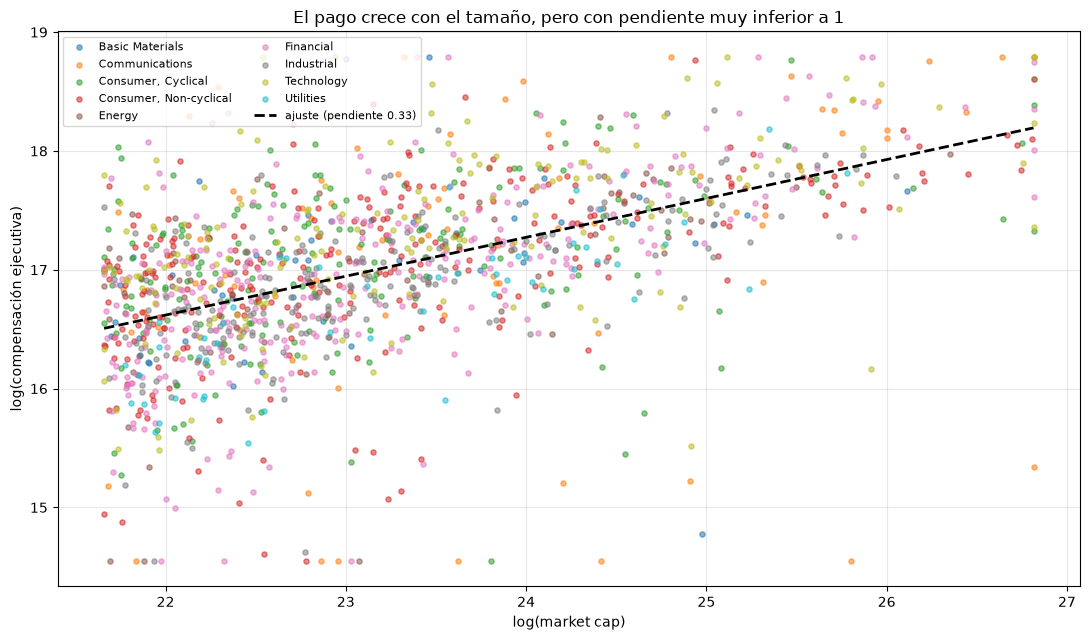

In [17]:
fig, ax = plt.subplots(figsize=(11, 6.5))
paleta = plt.cm.tab10(np.linspace(0, 1, d["Sector"].nunique()))
for (s, g), c in zip(d.groupby("Sector"), paleta):
    ax.scatter(g["l_MCAP"], g["l_CompEjec"], s=14, alpha=0.55, label=s, color=c)

x = np.linspace(d["l_MCAP"].min(), d["l_MCAP"].max(), 50)
ajuste = smf.ols("l_CompEjec ~ l_MCAP", data=d).fit()
ax.plot(
    x,
    ajuste.params.iloc[0] + ajuste.params.iloc[1] * x,
    "k--",
    lw=2,
    label=f"ajuste (pendiente {ajuste.params.iloc[1]:.2f})",
)
ax.set_xlabel("log(market cap)")
ax.set_ylabel("log(compensación ejecutiva)")
ax.set_title("El pago crece con el tamaño, pero con pendiente muy inferior a 1")
ax.legend(fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()
plt.show()

## 9. Exportación de resultados


In [18]:
salida = "resultados_compensacion.xlsx"
with pd.ExcelWriter(salida, engine="openpyxl") as w:
    nivel.to_excel(w, sheet_name="nivel_absoluto")
    razones.to_excel(w, sheet_name="razones_por_tamano")
    rank.to_excel(w, sheet_name="ranking_por_denominador")
    tabla_primas.to_excel(w, sheet_name="primas_de_sector")
    robustez.to_excel(w, sheet_name="robustez_sin_relevos")
    conc.to_excel(w, sheet_name="concentracion_CEO")
    top[cols[:-1] + ["prima_%"]].head(50).to_excel(
        w, sheet_name="top50_sobrepago", index=False
    )
    top[cols[:-1] + ["prima_%"]].tail(50).to_excel(
        w, sheet_name="top50_subpago", index=False
    )
print(f"Guardado: {salida}")

Guardado: resultados_compensacion.xlsx


## Conclusiones

1. **En nivel absoluto ganan Comunicaciones y Tecnología, pero eso es tamaño.** A nivel de
   empresa la compensación correlaciona con capitalización, ingresos y empleados con rho entre
   +0,4 y +0,5. Sin normalizar, la tabla no dice nada sobre generosidad.

2. **El ranking normalizado depende del denominador.** Por ingresos gana Tecnología; por
   empleado gana Energía; por puntos básicos de _market cap_ gana Materiales Básicos.
   Comunicaciones pasa del primer puesto al séptimo. Reportar una sola razón es elegir una
   conclusión.

3. **La elasticidad del pago al tamaño es ~0,34.** Las razones simples castigan a las empresas
   grandes por construcción. Este es el argumento para usar la regresión y no el cociente.

4. **Ajustado por tamaño, solo tres sectores se separan del promedio:** Tecnología paga un 38%
   de más; Servicios Públicos un 23% de menos e Industrial un 11% de menos. Los otros seis
   quedan en una banda de ±5% sin significancia estadística.

5. **El sobrepago de Tecnología está en el equipo, no en el CEO.** La prima del equipo
   ejecutivo (+38%) casi triplica la del CEO (+14%), y su razón CEO/Ejecutivos (42%) está entre
   las más bajas de la muestra.

6. **La junta se paga en un mercado aparte.** Su prima por sector no sigue a la de los
   ejecutivos: Consumo No Cíclico paga a su junta un 12% de más con un equipo ejecutivo en el
   promedio.

7. **Un relevo de CEO agrega ~30% al pago reportado del año, pero no cambia el ranking.**
   Excluir los 145 casos de relevo mueve las primas de sector menos de 2 puntos porcentuales.

**Límites.** Corte transversal de un solo año: mide asociación, no causalidad. No hay retorno
de la acción, así que no se puede evaluar si la prima de Tecnología está justificada por
desempeño. Las tres columnas de pago son totales reportados, sin descomposición entre efectivo,
acciones y opciones, y esa mezcla difiere sistemáticamente entre sectores.
